# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now = Time.now()
print(f"Current UTC time:{format_utc(now)}")
print(f"Current IITK time:{format_iitk(now)}")


Current UTC time:2026-09-06 13:44:46 UTC
Current IITK time:2026-09-06 19:14:46 IST


#### Answer: 
Two separate calls to ```Time.now()``` need not describe exactly the same instant because between the execution of each line of code there is a finite time difference which results in different instant.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
GTC_HEIGHT = 2396.0 * u.m
WAVELENGTH = 600.0 * u.nm
COORD_ERR = 5 * u.marcsec
CADENCE = 10 * u.min
FREQ = 1.4 * u.GHz

In [5]:
print(f"GTC Height = {GTC_HEIGHT, GTC_HEIGHT.to(u.km)}")
print(f"Frequency = {WAVELENGTH, WAVELENGTH.to(u.THz, equivalencies = u.spectral())}")
print(f"Coordinate Uncertainty = {COORD_ERR, COORD_ERR.to(u.arcsec)}")
print(f"Cadence = {CADENCE, CADENCE.to(u.h)}")
print(f"Wavelength = {FREQ, FREQ.to(u.cm, equivalencies = u.spectral())}")

GTC Height = (<Quantity 2396. m>, <Quantity 2.396 km>)
Frequency = (<Quantity 600. nm>, <Quantity 499.65409667 THz>)
Coordinate Uncertainty = (<Quantity 5. marcsec>, <Quantity 0.005 arcsec>)
Cadence = (<Quantity 10. min>, <Quantity 0.16666667 h>)
Wavelength = (<Quantity 1.4 GHz>, <Quantity 21.413747 cm>)


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [6]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
planning_start  = Time(START_UTC, scale = "utc")
print(f"Planning start time in UTC= {format_utc(planning_start)}")
planning_start.format = "jd"
print(f"Planning start time in JD = {planning_start.value}")
planning_start.format = "mjd"
print(f"Planning start time in MJD = {planning_start.value}")
print(f"Planning start at {format_iitk(planning_start)} IITK time")

add_time = 2.25 * u.h
planning_start += add_time
print(f"Planning start time after adding {add_time} = {format_utc(planning_start)}")
print(f"Planning start time after adding {add_time} = {format_iitk(planning_start)}")

planning_start_ist = planning_start.to_datetime(timezone=IITK_TIMEZONE)
print("Time difference from conversion:", np.abs(Time(planning_start_ist) - planning_start))

Planning start time in UTC= 2026-08-30 12:00:00 UTC
Planning start time in JD = 2461283.0
Planning start time in MJD = 61282.5
Planning start at 2026-08-30 17:30:00 IST IITK time
Planning start time after adding 2.25 h = 2026-08-30 14:15:00 UTC
Planning start time after adding 2.25 h = 2026-08-30 19:45:00 IST
Time difference from conversion: 0.0


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [7]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
FRB_RA_J2000 = Angle(FRB_RA_J2000)
FRB_DEC_J2000 = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(FRB_RA_J2000, FRB_DEC_J2000, frame = "icrs")
print("Coordinates in decimal degrees of FRB:", frb_icrs)
print("Padded Sexagesimal notation of FRB coordinates:", frb_icrs.to_string('hmsdms', pad = True))
print("Difference:", np.abs(347.2704120833 - frb_icrs.ra.deg), np.abs(48.7066410556 - frb_icrs.dec.deg))

Coordinates in decimal degrees of FRB: <SkyCoord (ICRS): (ra, dec) in deg
    (347.27041208, 48.70664106)>
Padded Sexagesimal notation of FRB coordinates: 23h09m04.8989s +48d42m23.9078s
Difference: 3.325340003357269e-11 4.4444448121794267e-11


#### Answer:
RA commonly uses hours while Dec uses degrees because of the very definition of RA - rotation of earth on its axis - which takes 24 hours in one day.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [8]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_gal = frb_icrs.transform_to("galactic")
print(frb_gal)
frb_icrs_back = frb_gal.transform_to("icrs")

sep = frb_icrs.separation(frb_icrs_back)
print(f"Separation between original and transformed back coordinates = {sep.to(u.arcsec)}")


<SkyCoord (Galactic): (l, b) in deg
    (106.06496077, -10.78417629)>
Separation between original and transformed back coordinates = 3.107329036068562e-10 arcsec


#### Answer:
The tiny non-zero residual represents the numerical round-off and floating point precision limits during forward and reverse transformation operation in 64-bit precision, and not a physical displacement of the source.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [9]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic)
print("Ecliptic longitude, lambda:", frb_ecliptic.lon)
print("Ecliptic latitude, beta:", frb_ecliptic.lat)

if frb_ecliptic.lon.deg >= 0 and frb_ecliptic.lon.deg <= 360:
    if frb_ecliptic.lat.deg >= -90 and frb_ecliptic.lat.deg <= 90:
        print("Ecliptic coordinates are within the valid range.")

frb_icrs_back = frb_ecliptic.transform_to("icrs")
sep = frb_icrs.separation(frb_icrs_back)
print(f"Separation between original and transformed back coordinates = {sep.to(u.uarcsec)}")

Ecliptic longitude, lambda: 14d24m40.27554122s
Ecliptic latitude, beta: 48d20m49.05037481s
Ecliptic coordinates are within the valid range.
Separation between original and transformed back coordinates = 0.0 uarcsec


#### Answer:
The ecliptic plane is the plane that is extended by the sun which holds the solar system. $\beta$ is the elevation of a target from the ecliptic plane.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [10]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
earlier_position = SkyCoord(EARLIER_POSITION_RA, EARLIER_POSITION_DEC, frame = "icrs")
print(type(earlier_position.ra))
print(type(frb_icrs.ra))
del_theta = np.sin(np.radians(frb_icrs.dec)) * np.sin(np.radians(earlier_position.dec)) + np.cos(np.radians(frb_icrs.dec)) * np.cos(np.radians(earlier_position.dec)) * np.cos(np.radians(frb_icrs.ra - earlier_position.ra))

print(del_theta)
print(np.clip(del_theta, -1.0, 1.0))
del_theta = np.arccos(del_theta)

del_theta_arcsec = del_theta.to(u.arcsec)
del_theta_marcsec = del_theta.to(u.marcsec)
print(f"Angular separation between the two positions = {del_theta_arcsec} = {del_theta_marcsec}")

print("Difference between manual calculation and separation():", np.abs(del_theta_arcsec - frb_icrs.separation(earlier_position).to(u.arcsec)))

<class 'astropy.coordinates.angles.core.Longitude'>
<class 'astropy.coordinates.angles.core.Longitude'>
0.9999999999738305
0.9999999999738305
Angular separation between the two positions = 1.4922374490540065 arcsec = 1492.2374490540062 marcsec
Difference between manual calculation and separation(): 2.27715e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [11]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(GTC_LONGITUDE_DEG * u.deg, GTC_LATITUDE_DEG * u.deg, GTC_HEIGHT_M * u.m)
print(gtc_location.geodetic)

GeodeticLocation(lon=<Longitude -17.889 deg>, lat=<Latitude 28.758 deg>, height=<Quantity 2396. m>)


### Answer:
Negative longitude means that the location falls westwards to the Greenwich Meridian

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [12]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
time = "2026-08-31T00:00:00Z"
time = Time(time, scale = "utc")

lst = time.sidereal_time("apparent", longitude = gtc_location.lon)
H = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC time = ", format_utc(time))
print("IITK time = ", format_iitk(time))
print("LST = ", lst)
print("Hour angle = ", H)

if H < 0 * u.deg:
    print("The target is east of the meridian.")
elif H > 0 * u.deg:
    print("The target is west of the meridian.")
else:
    print("The target is transiting.")



UTC time =  2026-08-31 00:00:00 UTC
IITK time =  2026-08-31 05:30:00 IST
LST =  21h25m12.20968715s
Hour angle =  -1h43m52.68921285s
The target is east of the meridian.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [13]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
lsts = times.sidereal_time("apparent", longitude = gtc_location.lon)
has = (lsts - frb_icrs.ra).wrap_at(12 * u.hourangle)

idx_transit = np.argmin(np.abs(has))
transit_time = times[idx_transit]
iitk_transit_time = format_iitk(transit_time)
lst_transit = lsts[idx_transit]
ha_transit = has[idx_transit]

print(f"Transit time index = {idx_transit}")
print(f"Transit time in UTC = {transit_time}")
print(f"Transit time in IITK = {iitk_transit_time}")
print(f"Transit LST = {lst_transit}")
print(f"Transit Hour Angle = {ha_transit}")


Transit time index = 82
Transit time in UTC = 2026-08-31T01:40:00.000
Transit time in IITK = 2026-08-31 07:10:00 IST
Transit LST = 23.091287933960785 hourangle
Transit Hour Angle = -0.060072871594769595 hourangle


#### Answer:
The above is a sampled approximation of the meridian transit rather than the exact transit instant because the ```times``` variable has discrete number of instances and the exact transit could be in between two of the samples. Thus to get a better approximation, number of samples can be increased.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [14]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
h_transit = 90 * u.deg - np.abs(GTC_LATITUDE_DEG * u.deg - frb_icrs.dec)
print("Altitude at transit = ", h_transit)
z = 90 * u.deg - h_transit
print("Zenith distance at transit = ", z)

altaz = AltAz(obstime = times, location = gtc_location)
frb_gtc_altaz = frb_icrs.transform_to(altaz)
max_alt = frb_gtc_altaz.alt.max()
max_zdist = 90*u.deg - max_alt

print(f"Maximum altitude from the sampled observation times = {max_alt}")
print(f"Maximum zenith distance from the sampled observation times = {max_zdist}")
print(f"Difference between the sampled maximum altitude and the transit altitude = {np.abs(max_alt - h_transit)}")

Altitude at transit =  70d03m04.8922s
Zenith distance at transit =  19d56m55.1078s
Maximum altitude from the sampled observation times = 69.88390842641054 deg
Maximum zenith distance from the sampled observation times = 20.116091573589458 deg
Difference between the sampled maximum altitude and the transit altitude = 0.16745051803390254 deg


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [15]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

idx_pre = np.argmin(np.abs(has-(-2*u.hourangle)))
idx_post = np.argmin(np.abs(has-(2*u.hourangle)))

h_pre = np.arcsin(np.sin(gtc_location.lat)*np.sin(frb_icrs.dec) + np.cos(gtc_location.lat)*np.cos(frb_icrs.dec)*np.cos(has[idx_pre]))
h_post = np.arcsin(np.sin(gtc_location.lat)*np.sin(frb_icrs.dec) + np.cos(gtc_location.lat)*np.cos(frb_icrs.dec)*np.cos(has[idx_post]))
alt_transit = np.arcsin(np.sin(gtc_location.lat)*np.sin(frb_icrs.dec) + np.cos(gtc_location.lat)*np.cos(frb_icrs.dec)*np.cos(has[idx_transit]))

print(f"UTC:{times[idx_pre]}, {times[idx_transit]}, {times[idx_post]}")
print(f"IST:{format_iitk(times[idx_pre])}, {format_iitk(times[idx_transit])}, {format_iitk(times[idx_post])}")
print(f"HA:{has[idx_pre]}, {has[idx_transit]}, {has[idx_post]}")
print(f"Calculated Altitude:{h_pre.to(u.deg)}, {alt_transit.to(u.deg)}, {h_post.to(u.deg)}")
print(f"Astropy Altitude:{frb_gtc_altaz[idx_pre].alt}, {max_alt}, {frb_gtc_altaz[idx_post].alt}")
print(f"Difference between calculated altitude and astropy altitude:", {np.abs(h_pre.to(u.deg)-frb_gtc_altaz[idx_pre].alt)}, {np.abs(alt_transit.to(u.deg)-max_alt)}, {np.abs(h_post.to(u.deg)-frb_gtc_altaz[idx_post].alt)})

UTC:2026-08-30T23:40:00.000, 2026-08-31T01:40:00.000, 2026-08-31T03:40:00.000
IST:2026-08-31 05:10:00 IST, 2026-08-31 07:10:00 IST, 2026-08-31 09:10:00 IST
HA:-2.065548496014628 hourangle, -0.060072871594769595 hourangle, 1.9454027564772716 hourangle
Calculated Altitude:59.03195220623935 deg, 70.0393476330852 deg, 60.06304021709357 deg
Astropy Altitude:58.78157558803205 deg, 69.88390842641054 deg, 60.162602965034445 deg
Difference between calculated altitude and astropy altitude: {<Angle 0.25037662 deg>} {<Angle 0.15543921 deg>} {<Angle 0.09956275 deg>}


#### Answer:
As the source starts from - 2h (HA) and moves towards the meridian, there is an increase in the altitude and as it goes further to +2h (HA) the altitude decreases depicting the rising and setting of a source.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [16]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
h_min = MIN_TARGET_ALTITUDE_DEG*u.deg
num = np.sin(h_min)-np.sin(gtc_location.lat)*np.sin(frb_icrs.dec)
den = np.cos(gtc_location.lat)*np.cos(frb_icrs.dec)
H_0 = np.arccos(num/den)
print("H_0 in degrees:", H_0.to(u.deg))
print("H_0 in sidereal hours:", H_0.to(u.hourangle))

interval = 2*H_0.to(u.hourangle)
print("Total interval:", interval)

idx_interval = frb_gtc_altaz.alt > h_min
print("Total interval from the samples:", has[idx_interval].max()-has[idx_interval].min())

H_0 in degrees: 91.92747700350239 deg
H_0 in sidereal hours: 6.12849846690016 hourangle
Total interval: 12.25699693380032 hourangle
Total interval from the samples: 12h11m59.91621272s


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [17]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass = np.array([float(x) for x in frb_gtc_altaz.secz])
target_airmass[(frb_gtc_altaz.alt<=0*u.deg) | (~np.isfinite(target_airmass)) | (target_airmass < 1.0)] = np.nan
print(f"Finite range:{np.nanmin(target_airmass)} to {np.nanmax(target_airmass)}")
print(f"Best airmass:{np.nanmin(target_airmass)}")
idx_best = np.nanargmin(target_airmass)
print(f"UTC at best airmass:{times[idx_best]}")
print(f"IST at best airmass:{format_iitk(times[idx_best])}")

samples_best = target_airmass[(target_airmass>=1.0) & (target_airmass<=MAX_AIRMASS)]
print(f"Number of samples which have airmass in the range [1, 2.5]: {len(samples_best)}")

Finite range:1.064965337215341 to 55.33881158576406
Best airmass:1.064965337215341
UTC at best airmass:2026-08-31T01:40:00.000
IST at best airmass:2026-08-31 07:10:00 IST
Number of samples which have airmass in the range [1, 2.5]: 68


#### Answer: 
Below-horizon values must not be used simply because they are not visible to the observer as they go beyond the horizon and the airmass values would not make any sense. 

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [18]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
import warnings
warnings.simplefilter('ignore', astropy.coordinates.baseframe.NonRotationTransformationWarning)

sun = get_sun(times)
moon = get_body('moon', times, gtc_location)

altaz_frame = AltAz(obstime = times, location = gtc_location)

sun_altaz = sun.transform_to(altaz_frame)
moon_altaz = moon.transform_to(altaz_frame)

moon_airmass = moon_altaz.secz
moon_target_sep = moon_altaz.separation(frb_gtc_altaz)
epsilon = sun.separation(moon)

f = (1.0-np.cos(epsilon))/2.0
moon_airmass_select = moon_airmass[(moon_airmass>=1) & (moon_airmass<=3) & (moon_altaz.alt>=0)]
moon_labels = []

for m_alt, m_tar, m_f in zip(moon_altaz.alt, moon_target_sep, f):
    unknown = (~np.isfinite(m_alt)) | (~np.isfinite(m_tar)) | (~np.isfinite(m_f))
    isbright = (m_f>=0.70) & (m_alt > 10*u.deg) | (m_tar <= 45*u.deg)
    isdark = (m_alt < 0*u.deg) | (m_tar >= 90*u.deg) & (m_f<=0.25)
    if unknown: 
        label = "Unknown"
    else:
        label = "Gray"
        if isbright:
            label = "Bright"
        elif isdark:
            label = "Dark"

    moon_labels.append(label)
moon_labels = np.array(moon_labels)

print(f"Sun altitude at trainsit:{sun_altaz.alt[idx_transit]}")
print(f"Moon Altitude at transit:{moon_altaz.alt[idx_transit]}")
print(f"Moon airmass at transit:{moon_airmass[idx_transit]}")
print(f"Moon target separation at transit:{moon_target_sep[idx_transit]}")
print(f"Approximate illuminated fraction at transit:{f[idx_transit]}")
print(f"Label:{moon_labels[idx_transit]}")


Sun altitude at trainsit:-51.95592540251873 deg
Moon Altitude at transit:59.095910817680405 deg
Moon airmass at transit:1.1654627890993672
Moon target separation at transit:45.22675347563805 deg
Approximate illuminated fraction at transit:0.9081715559773917
Label:Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [19]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(altitude, airmass, sun_altitude, moon_separation):
    shapes = [np.shape(x) for x in (altitude, airmass, sun_altitude, moon_separation)]
    if all(len(s)==1 for s in shapes) and all(s == shapes[0] for s in shapes):
        print("There are 4 equal 1D arrays")
    cond_alt = (altitude>=MIN_TARGET_ALTITUDE_DEG*u.deg)
    cond_air = (airmass >=1) & (airmass<=MAX_AIRMASS) & (np.isfinite(airmass))
    cond_sun_alt = (sun_altitude <= MAX_SUN_ALTITUDE_DEG*u.deg)
    cond_m_sep = (moon_separation >= MIN_MOON_SEPARATION_DEG*u.deg)
    return cond_alt & cond_air & cond_sun_alt & cond_m_sep

cond_alt = (frb_gtc_altaz.alt>=MIN_TARGET_ALTITUDE_DEG*u.deg)
cond_air = (target_airmass >=1) & (target_airmass<=MAX_AIRMASS) & (np.isfinite(target_airmass))
cond_sun_alt = (sun_altaz.alt <= MAX_SUN_ALTITUDE_DEG*u.deg)
cond_m_sep = (moon_target_sep >= MIN_MOON_SEPARATION_DEG*u.deg)

preferred_visibility = visibility(frb_gtc_altaz.alt, target_airmass, sun_altaz.alt, moon_target_sep)

print("Target altitude condition count:", np.sum(cond_alt))
print("Target airmass condition count:", np.sum(cond_air))
print("Target sun altitude condition count:", np.sum(cond_sun_alt))
print("Target moon separation condition count:", np.sum(cond_m_sep))
print(f"Visibility:{np.sum(visibility)}")
if np.sum(visibility) == 0:
    print("Visibility = NO")
else:
    print("Visibility = YES")

There are 4 equal 1D arrays
Target altitude condition count: 74
Target airmass condition count: 68
Target sun altitude condition count: 51
Target moon separation condition count: 145
Visibility:<function visibility at 0x7f652d79f8a0>
Visibility = YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [20]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

obs_time = Time("2026-08-31T06:00:00Z")
idx_0600 = np.argmin(np.abs(obs_time-times))

print("Transit Time vs Observing Time")
print(f"UTC:{transit_time} and {times[idx_0600]}")
print(f"IST:{iitk_transit_time} and {format_iitk(times[idx_0600])}")
print(f"Altitude:{max_alt} and {frb_gtc_altaz.alt[idx_0600]}")
print(f"Airmass:{target_airmass[idx_transit]} and {target_airmass[idx_0600]}")
print(f"Sun altitude:{sun_altaz.alt[idx_transit]} and {sun_altaz.alt[idx_0600]}")
print(f"Moon separation:{moon_target_sep[idx_transit]} and {moon_target_sep[idx_0600]}")

print(f"Altitude condition:{cond_alt[idx_transit]} and {cond_alt[idx_0600]}")
print(f"Airmass condition:{cond_air[idx_transit]} and {cond_air[idx_0600]}")
print(f"Sun altitude condition:{cond_sun_alt[idx_transit]} and {cond_sun_alt[idx_0600]}")
print(f"Moon separation condition:{cond_m_sep[idx_transit]} and {cond_m_sep[idx_0600]}")

print(f"Visibility:{preferred_visibility[idx_transit]} and {preferred_visibility[idx_0600]}")


Transit Time vs Observing Time
UTC:2026-08-31T01:40:00.000 and 2026-08-31T06:00:00.000
IST:2026-08-31 07:10:00 IST and 2026-08-31 11:30:00 IST
Altitude:69.88390842641054 deg and 37.986479632663226 deg
Airmass:1.064965337215341 and 1.624760023698483
Sun altitude:-51.95592540251873 deg and -11.282033067352096 deg
Moon separation:45.22675347563805 deg and 44.69814585810848 deg
Altitude condition:True and True
Airmass condition:True and True
Sun altitude condition:True and False
Moon separation condition:True and True
Visibility:True and False


#### Answer:
Even though the object has high altitude and meridian transit occurs, it does not guarantee observability because if there is sun or moon near the object then the visibility of the object reduces. This in turn makes the observation difficult, resulting in poor, low SNR data. For example, if the sun's altitude is greater than -18 degrees, it means that the observing time is right around/after the sunset. Thus the twilight sky would contaminate the data. Similarly if the target is within 30 degrees from the moon, the moonlight can contaminate the data. The above comparison suggests the same.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Interval 1 in UTC:('2026-08-30T21:00:00.000', '2026-08-31T05:20:00.000')
Interval 1 in IIT Kanpur time:2026-08-31 02:30:00 IST, 2026-08-31 10:50:00 IST
Sample-centre duration for interval 1:8.333333333333332 h
Best target airmass for interval 1:1.064965337215341
Midpoint Moon Label:Bright


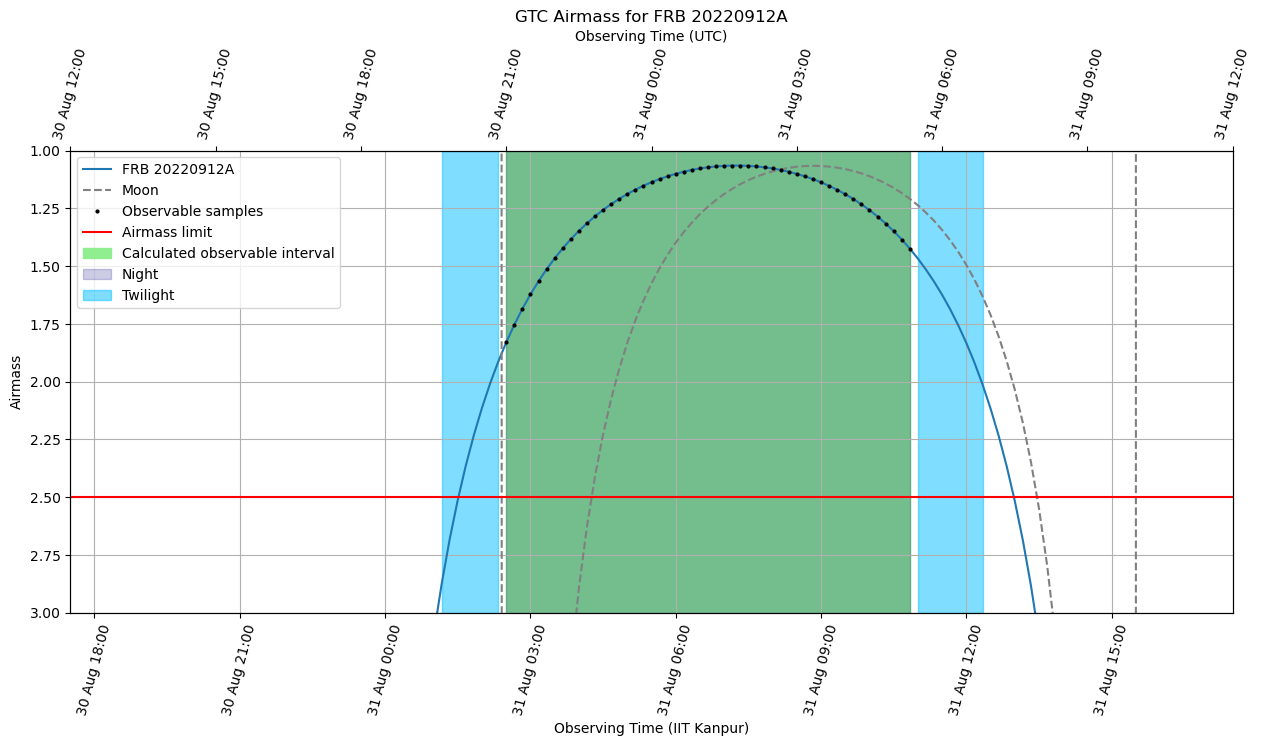

In [21]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def stitch_windows(times, visibility_state):
    idx_start = []
    idx_stop = []
    check = False
    for i in range(len(visibility_state)):
        if visibility_state[i] and not check:
            idx_start.append(i)
            check = True
        elif not visibility_state[i] and check:
            idx_stop.append(i-1)
            check = False
    if check:
        idx_stop.append(len(visibility_state)-1)


    return idx_start, idx_stop, times[idx_start], times[idx_stop]

idx_start, idx_stop, start_time, stop_time = stitch_windows(times, preferred_visibility)

for i in range(len(start_time)):
    print(f"Interval {i+1} in UTC:{start_time[i].value, stop_time[i].value}")
    print(f"Interval {i+1} in IIT Kanpur time:{format_iitk(start_time[i])}, {format_iitk(stop_time[i])}")
    print(f"Sample-centre duration for interval {i+1}:{(stop_time[i]-start_time[i]).to(u.hour)}")
    print(f"Best target airmass for interval {i+1}:{np.min(target_airmass[idx_start[i]:idx_stop[i]])}")
    print(f"Midpoint Moon Label:{moon_labels[(idx_stop[i]+idx_start[i])//2]}")

for start, stop in zip(idx_start, idx_stop):
    t_start_ist = (times[start]+5.5*u.hour).to_datetime()
    t_stop_ist = (times[stop]+5.5*u.hour).to_datetime()

times_ist = (times+5.5*u.hour).to_datetime()
times_utc = times.to_datetime()

night_mask = sun_altaz.alt <= -18 * u.deg
twilight_mask = (sun_altaz.alt > -18 * u.deg) & (sun_altaz.alt <= 0 * u.deg)

fig, ax1 = plt.subplots(figsize = (15, 6))
ax1.tick_params(axis = 'x', labelrotation = 75)
ax1.plot(times_ist, target_airmass, label = FRB_NAME)
ax1.plot(times_ist, moon_airmass, linestyle = '--', color='grey', label = 'Moon')
ax1.plot(np.array(times_ist)[preferred_visibility], np.array(target_airmass)[preferred_visibility], 'k.' , markersize='4', label='Observable samples')
ax1.axhline(2.5, color = 'red', label='Airmass limit')
ax1.set_xlim(times_ist[0],times_ist[-1])
ax1.set_xlabel('Observing Time (IIT Kanpur)')
ax1.axvspan(t_start_ist, t_stop_ist,color = 'lightgreen', label='Calculated observable interval')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))
ax1.set_ylim(3.0,1.0)
ax1.grid()
ax1.set_title(f"GTC Airmass for {FRB_NAME}")
ax1.set_ylabel("Airmass")
ax1.fill_between(times_ist, 1.0, 3.0, where=night_mask, color='navy', alpha=0.2, label='Night')
ax1.fill_between(times_ist, 1.0, 3.0, where=twilight_mask, color='deepskyblue', alpha = 0.5, label='Twilight')
ax1.legend()

ax2 = ax1.twiny()
ax2.set_xlim(times_utc[0],times_utc[-1])
ax2.set_xlabel('Observing Time (UTC)')
ax2.tick_params(axis = 'x', labelrotation = 75)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %H:%M'))

fig.savefig("assignment_outputs/frb_20220912a_gtc_airmass.png")


#### Answer: 
From the plots, we can conclude that the source can be observed exceptionally good during the proposed observation night-falls within the astronomical night, pronounced separation from the moon, transit at minimum airmass. These conditions favour obtaining good quality photometric or spectroscopic data with no background contamination.

The shortcoming of the 10 minute grid sampling is that the exact entry and exit boundaries are calculated discretely. Thus it introduces timing uncertainty about $\pm$ 10 minutes at both window boundaries, potentially overestimating or underestimating the true continuous duration by up to one full sampling interval.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [22]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

start_q19 = Time("2026-09-01T00:00:00", scale="utc")
stop_q19 = Time("2026-09-02T00:00:00", scale="utc")
times_q19 = start_q19 + np.arange(145) * (10 * u.min)

altaz_q19 = AltAz(obstime=times_q19, location=gtc_location)
target_alt = frb_icrs.transform_to(altaz_q19).alt
sun_alt = get_sun(times_q19).transform_to(altaz_q19).alt

cond_sun = sun_alt <= -18 * u.deg
cond_alt = target_alt > 0 * u.deg
cond_air = (target_alt >= np.arcsin(1.0 / 2.5) * u.rad)

q19_visibility = cond_sun & cond_alt & cond_air

idx_start, idx_stop, start_t, stop_t = stitch_windows(times_q19, q19_visibility)

total_dur = 0.0 * u.hour
for i in range(len(start_t)):
    dur = (stop_t[i] - start_t[i]).to(u.hour)
    total_dur += dur
    print(f"Interval {i+1} in UTC: {start_t[i].value} to {stop_t[i].value}")
    print(f"Interval {i+1} in IIT Kanpur time: {format_iitk(start_t[i])} to {format_iitk(stop_t[i])}")
    print(f"Sample-centre duration: {dur} ({dur.to(u.minute)})\n")

print(f"Total visible duration in hours: {total_dur}")


Interval 1 in UTC: 2026-09-01T00:00:00.000 to 2026-09-01T05:20:00.000
Interval 1 in IIT Kanpur time: 2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Sample-centre duration: 5.333333333333333 h (320.0 min)

Interval 2 in UTC: 2026-09-01T21:00:00.000 to 2026-09-02T00:00:00.000
Interval 2 in IIT Kanpur time: 2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Sample-centre duration: 3.0 h (180.0 min)

Total visible duration in hours: 8.333333333333332 h


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [22]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
